In [108]:
import pandas as pd
import numpy as np
import torch
from clearml import Task
from collections import defaultdict
from matplotlib import pyplot as plt
from scipy.stats import gaussian_kde

In [109]:
%env CLEARML_WEB_HOST=https://app.clear.ml/
%env CLEARML_API_HOST=https://api.clear.ml
%env CLEARML_FILES_HOST=https://files.clear.ml
%env CLEARML_API_ACCESS_KEY=ABP1QYAF3E5FG24SDKULXIR2ESEUNL
%env CLEARML_API_SECRET_KEY=EeLEn8EveqxBKL7oBo1-TnIh2gMXw70D-3_EbH57gdVbMrywzLEcBSx_vAzHe-ul45o

env: CLEARML_WEB_HOST=https://app.clear.ml/
env: CLEARML_API_HOST=https://api.clear.ml
env: CLEARML_FILES_HOST=https://files.clear.ml
env: CLEARML_API_ACCESS_KEY=ABP1QYAF3E5FG24SDKULXIR2ESEUNL
env: CLEARML_API_SECRET_KEY=EeLEn8EveqxBKL7oBo1-TnIh2gMXw70D-3_EbH57gdVbMrywzLEcBSx_vAzHe-ul45o


In [212]:
def select_best(reports):
    res = {}
    for k,v in reports.items():
        #select_val = [m["metrics"]["Summary"]["test_ndcg@20"]["max"] if "Summary" in m["metrics"] else -1 for m in v]
        select_val = []
        for m in v:
            r = -1
            try:
                r = m["metrics"]["Summary"]["test_ndcg@10"]["max"]
                if not "singular_values_seq" in m["artefacts"]:
                    #print("FUCKED")
                    r = -1
                    1/0
            except Exception:
                pass
            select_val.append(r)
            
        select_idx = np.argmax(select_val)
        best = v[select_idx]
        res[k] = best
    return res


def get_max_m(rep):
    metr = rep["metrics"]["Summary"]
    return {k:v["max"] for k,v in metr.items()}
def to_df(reports):
    
    return pd.DataFrame(
        index = reports.keys(),
        data = [get_max_m(v) for v in reports.values() ]
    )


def calc_impr(df, bt_name):
    df = df.copy()
    imp = df.loc[bt_name]
    for name, row in df.iterrows():
        if name == bt_name:
            continue
        delta = ((imp - row) / row * 100).values
        df.loc[ f"Imp {bt_name} / {name}" ] = delta
    return df

def plot_sing_val_norm(g, mode="seq", show_legend = False):
    ren = {"BCE": "SasRec(BCE)", "Scalable CE": "SasRec(SCE)", "Barlow twins": "BT-SR", "Full CE": "SasRec(CE)", "DuoRec": "DuoRec"}
    for l,v in g.items():
        sv = v["artefacts"][f"singular_values_{mode}"].get().copy()[:60]
        if "barlow twins" in l.lower():
            pass
        sv = sv / sv.max() #(sv - sv.min()) / (sv.max()-sv.min())
        #ll = l.replace("ML1M", "").replace('.', '').replace('  ', '')
        for r, rn in ren.items():
            if r in l:
                ll = rn
        if ll == "SasRec(BCE)":
            continue
        sve = -(sv * np.log(sv + 1e-6)).sum()
        plt.plot(sv, label=f"{ll} (Stable rk={sve:.2f})")
    if show_legend:
        plt.legend(fontsize=16)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

def plot_sing_val(g, mode="seq"):
    for l,v in g.items():
        sv = v["artefacts"][f"singular_values_{mode}"].get()[:60]
        plt.plot(sv, label=l)
    plt.legend()
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)

def plot_embeddings_art0(g, mode="seq"):
    import umap
    fig, axs = plt.subplots(1,3, figsize=(24, 7), sharey = True, sharex=True)
    

    for i, (k,v) in enumerate(g.items()):
        X_emb = v["artefacts"][f"embeddings_{mode}"].get()
        reducer = umap.UMAP(n_components=2, n_jobs=16)
        X_2d = reducer.fit_transform(X_emb)

        kde = gaussian_kde(X_2d.T)
        density = kde(X_2d.T)
        scatter = axs[i].scatter(X_2d[:, 0], X_2d[:, 1], c=density, s=20, cmap='viridis')
        axs[i].set_title(k)
        plt.colorbar(scatter, ax=axs[i], label='Density')

def plot_embeddings_art(g, mode="seq", font_scale: float = 1.4):
    # first pass: compute 2D embeddings & densities
    import umap

    plt.style.use('seaborn-v0_8-white')
    base_size = 12 * font_scale
    plt.rcParams.update({
        "font.size": base_size,
        "axes.titlesize": base_size * 1.2,
        "axes.labelsize": base_size,
        "figure.titlesize": base_size * 1.2,
        "legend.fontsize": base_size * 0.9,
        "xtick.labelsize": base_size * 0.9,
        "ytick.labelsize": base_size * 0.9,
    })

    all_results = []
    for k, v in g.items():
        X_emb = v["artefacts"][f"embeddings_{mode}"].get()
        reducer = umap.UMAP(n_components=2, n_jobs=16)
        X2 = reducer.fit_transform(X_emb)
        dens = gaussian_kde(X2.T)(X2.T)
        all_results.append((k, X2, dens))

    # find global min/max density
    all_dens = np.hstack([dens for (_, _, dens) in all_results])
    vmin, vmax = all_dens.min(), all_dens.max()

    # now plot with common color scale
    fig, axs = plt.subplots(1, len(all_results), figsize=(24, 7), sharex=True, sharey=True)
    for ax, (k, X2, dens) in zip(axs, all_results):
        sc = ax.scatter(X2[:,0], X2[:,1],
                        c=dens, s=20, cmap='viridis',
                        vmin=vmin, vmax=vmax)
        ax.set_title(k)

    # one colorbar for all
    fig.colorbar(sc, ax=axs, orientation='vertical', label='Density')
    #plt.tight_layout()
    #plt.show()

def average_entropy(logits):
    # Apply softmax to each row for numerical stability
    exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
    
    # Calculate entropy for each row; add a small constant for numerical stability in log
    entropy = -np.sum(probabilities * np.log(probabilities + 1e-12), axis=1)
    
    # Return the average entropy over all rows
    return np.mean(entropy)

def get_avg_entropy(g):
    for i, (k,v) in enumerate(g.items()):
        logits = v["artefacts"]["test_logits"].get()
        entropy = average_entropy(logits)
        print(f"{k}: {entropy:.4f}")
              

def uniformity(origin_z, batch_size, dist="dot"):
    """
    We do not sample negative examples explicitly.
    Instead, given a positive pair, similar to (Chen et al., 2017), we treat the other 2(N − 1) augmented examples within a minibatch as negative examples.
    """

    # pairwise l2 distace
    if dist == 'dot':
        sim = origin_z@origin_z.T
    elif dist == "cos":
        origin_z = origin_z / torch.norm(origin_z, p=2)
        sim = origin_z@origin_z.T
    elif dist == 'l2':
        sim = torch.cdist(origin_z, origin_z, p = 2)
    mask = torch.ones((batch_size, batch_size), dtype=bool)
    mask = mask.fill_diagonal_(0)
    negative_samples = sim[mask].reshape(batch_size, -1)
    uniformity = torch.log(torch.exp(-2 * negative_samples).mean())
    
    return uniformity

def get_uniformity(g, mode="seq", dist="dot"):
    for i, (k,v) in enumerate(g.items()):
        embs = v["artefacts"][f"embeddings_{mode}"].get()
        embs = torch.tensor(embs[:2000])
        unif = uniformity(embs, embs.shape[0], dist=dist)
        print(f"{k}: {unif:.4f}")

def plot_uniformity_vs_ndcg(g):
    for i, (k,v) in enumerate(g.items()):
        print(v.keys())
        unifs = v["scalars"]["Uniformity"]["Val"]["y"]
        ndcgs = v["scalars"]["NDCG"]["Val"]["y"]
        plt.scatter(unifs, ndcgs, label=k)
    plt.xlabel("Uniformity")
    plt.ylabel("NDCG")
    plt.legend()
    plt.show()


In [111]:
#get_uniformity(ml_reports_best, mode="item", dist="l2")
#plot_uniformity_vs_ndcg(yelp_reports_best)

In [112]:
project = "BTSasRec"

In [162]:
#tasks = Task.get_tasks(project_name=project)
d_task_ids = {
    "MovieLens 1M": {
        "BT": "f257ebe1ce8749e1a5fba54b0c59ff3c",
        "BCE": "a4e50afbc71549728f6ca7ef108e3291",
        "FCE": "ba81ff69615046dd867243c47105db2f",
        "SCE": "3b0b07003b7c433ca95139446ccae368",
        "DuoRec": "c06d04c89aaa4497b57f9fdff3e03043"
    },
    "YELP": {
        "BT": "d1787bf27f174ca59ab8975d18bb08f4",
        "BCE": "ad50f2447ad94227b347a09c6b8d1ced",
        "FCE": "0bce2180ed7a4ac99ed0a4badafec12d", #"7a1b8b91e42b4fc1ade15034d79918b6",
        "SCE": "79d31a7ec0524bdca4c0608754319df5",
        "DuoRec": "c87ad1f488694b3f90ba93c6cbac3ac6"
    },
    "Gowalla": {
        "BT": "7faea67c91fa4d238df04aebcaa9df02",
        "BCE": "3596ae5f14d34f73a1d802685c4ef503",
        "FCE": "85c14515dc2447069e7efb5a94af98ab",
        "SCE": "c98dcaa9fa5646b692df74f814de2cf3",
        "DuoRec": "1c6960603e2f44e58d797212a34b39a5"
    },
    "Beauty": {
        "BT": "4ef7ce26733049a9a69863c18d497ec2", #"59bbd539ce96427dacdf283dfbc6c235",
        "BCE": "c21a7bafa4714bcf8fdc23985c072452",
        "FCE": "47f5120abb48435982b05d82b5b5da93",
        "SCE": "7853d6c4b2ed43108563d29040ca76fd",
        "DuoRec": "8e32761d3c2f420fb99cc5bb7b3bd218"
    },
    "Kindle Store": {
        "BT": "ac85ccdc185d43c68052488262e659c3",
        "BCE": "25e26787537841a9aa977a1daf4f7d26",
        "FCE": "008c8e00b7db46c68dbd7d3fa75476d5",
        "SCE": "251e961552f74b9fae7bf0c8fec5a7a5",
        "DuoRec": "c40229a518ae453aa385f84a58b5aaab"
    }
}
tasks = []
for d, ts in d_task_ids.items():
    for k,v in ts.items():
        tasks.append(v)
tasks = Task.get_tasks(task_ids=tasks)

reports = defaultdict(list)
for t in tasks:
    print(t.name)
    if t.name == "CE Barlow twins":
        continue
    art = {}
    art["scalars"] = t.get_reported_scalars()
    art["metrics"] = t.get_last_scalar_metrics()
    art["parameters"] = t.get_parameters()
    art["artefacts"] = t.artifacts
    reports[t.name].append(art)

ML1M. CE Barlow twins
ML1M. BCE
Full CE
Scalable CE
ML1M. DuoRec
YELP. CE Barlow twins
YELP. BCE
YELP. Full CE
YELP. Scalable CE
YELP. DuoRec
Gowalla. CE Barlow twins
Gowalla. BCE
Gowalla. Full CE
Gowalla. Scalable CE
Gowalla. DuoRec
Beauty. CE Barlow twins
Beauty. BCE
Beauty. Full CE
Beauty. Scalable CE
Beauty. DuoRec
Kindle Store. Scalable CE Barlow Twins
Kindle Store. BCE
Kindle Store. Full CE
Kindle Store. Scalable CE
Kindle Store. DuoRec


In [ ]:
from collections import OrderedDict

ec4rec_metrics = {
    "ML1M": OrderedDict([
        ('hit@1', 0.0250), ('hit@5', 0.0523), ('hit@10', 0.0863), 
        ('ndcg@5', 0.0381), ('ndcg@10', 0.0478), ('ndcg@50', 0.0803),
        ('cov@1', 0.0353), ('cov@5', 0.2026), ('cov@10', 0.3185),
    ]),
    "YELP": OrderedDict([
        ('hit@1', ), ('hit@5', ), ('hit@10', ), 
        ('ndcg@5', ), ('ndcg@10', ), ('ndcg@50', ),
        ('cov@1', ), ('cov@5', ), ('cov@10', ),
    ]),
}

In [114]:
yelp_reports = {k:v for k,v in reports.items() if 'YELP' in k}
ml_reports = {k:v for k,v in reports.items() if 'YELP' not in k and 'Gowalla' not in k and not 'Beauty' in k and not 'Kindle Store' in k}
gowall_reports = {k:v for k,v in reports.items() if 'Gowalla' in k}
beauty_reports = {k:v for k,v in reports.items() if 'Beauty' in k}
ks_reports = {k:v for k,v in reports.items() if 'Kindle Store' in k}

In [115]:
#del ml_reports["CE Barlow twins"]

In [116]:
ml_reports_best = select_best(ml_reports)
ml_metr_df = to_df(ml_reports_best).filter(regex='^test_')



In [117]:
yelp_reports_best = select_best(yelp_reports)
yelp_metr_df = to_df(yelp_reports_best).filter(regex='^test_')

In [118]:
gw_reports_best = select_best(gowall_reports)
gw_metr_df = to_df(gw_reports_best).filter(regex='^test_')

In [119]:
bu_reports_best = select_best(beauty_reports)
bu_metr_df = to_df(bu_reports_best).filter(regex='^test_')

In [120]:
ks_reports_best = select_best(ks_reports)
ks_metr_df = to_df(ks_reports_best).filter(regex='^test_')

In [121]:
metrics_take = ["test_hr@1", "test_hr@5", "test_hr@10", "test_ndcg@5", "test_ndcg@10", "test_ndcg@50", "test_cov@1", "test_cov@5", "test_cov@10"]
#metrics_take_buckets = [ for m in ["test_hr@1", "test_ndcg@10", "test_cov@10"] ]

## YELP

In [122]:
metr_ye = calc_impr(yelp_metr_df[metrics_take], bt_name = 'YELP. CE Barlow twins')
metr_ye

,test_hr@1,test_hr@5,test_hr@10,test_ndcg@5,test_ndcg@10,test_ndcg@50,test_cov@1,test_cov@5,test_cov@10
YELP. CE Barlow twins,0.004900,0.018300,0.028800,0.011700,0.015000,0.026700,0.021800,0.063600,0.099800
YELP. BCE,0.004500,0.016200,0.029200,0.010400,0.014600,0.028000,0.010300,0.033300,0.054100
YELP. Full CE,0.004300,0.013700,0.025700,0.008800,0.012700,0.026300,0.023300,0.062100,0.091100
YELP. Scalable CE,0.004000,0.015200,0.027700,0.009700,0.013700,0.025800,0.013500,0.041300,0.066100
YELP. DuoRec,0.002700,0.009400,0.018800,0.006100,0.009100,0.017200,0.005900,0.016100,0.025500
Imp YELP. CE Barlow twins / YELP. BCE,8.888889,12.962963,-1.369863,12.500000,2.739726,-4.642857,111.650485,90.990991,84.473198
Imp YELP. CE Barlow twins / YELP. Full CE,13.953488,33.576642,12.062257,32.954545,18.110236,1.520913,-6.437768,2.415459,9.549945
Imp YELP. CE Barlow twins / YELP. Scalable CE,22.500000,20.394737,3.971119,20.618557,9.489051,3.488372,61.481481,53.995157,50.983359
Imp YELP. CE Barlow twins / YELP. DuoRec,81.481481,94.680851,53.191489,91.803279,64.835165,55.232558,269.491525,295.031056,291.372549


In [186]:
metr_b_ye = yelp_metr_df.filter(regex='test_Bucket_*').filter(regex='hr@1|hr@5|hr@20|ndcg@10|cov@10')
calc_impr(metr_b_ye, bt_name = 'YELP. CE Barlow twins').sort_index(axis=1)

,test_Bucket_1 cov@10,test_Bucket_1 hr@1,test_Bucket_1 hr@10,test_Bucket_1 hr@20,test_Bucket_1 hr@5,test_Bucket_1 hr@50,test_Bucket_1 ndcg@10,test_Bucket_2 cov@10,test_Bucket_2 hr@1,test_Bucket_2 hr@10,...,test_Bucket_2 hr@5,test_Bucket_2 hr@50,test_Bucket_2 ndcg@10,test_Bucket_3 cov@10,test_Bucket_3 hr@1,test_Bucket_3 hr@10,test_Bucket_3 hr@20,test_Bucket_3 hr@5,test_Bucket_3 hr@50,test_Bucket_3 ndcg@10
YELP. CE Barlow twins,0.039000,0.018900,0.101900,0.152100,0.067400,0.245400,0.054500,0.054700,0.002900,0.022200,...,0.012400,0.093000,0.010800,0.076000,0.0002,0.001600,0.003000,0.000900,0.007900,0.000800
YELP. BCE,0.025500,0.014500,0.078100,0.115800,0.049000,0.183100,0.041400,0.033600,0.004700,0.031600,...,0.015300,0.123300,0.015200,0.044000,0.0000,0.006700,0.013400,0.002800,0.032000,0.002600
YELP. Full CE,0.041000,0.011800,0.065200,0.101200,0.035500,0.206200,0.033300,0.054600,0.005100,0.033500,...,0.018200,0.123600,0.016300,0.072300,0.0005,0.003700,0.006900,0.001400,0.018500,0.001600
YELP. Scalable CE,0.027700,0.017300,0.095500,0.147800,0.056100,0.228700,0.050100,0.039100,0.001500,0.022200,...,0.010200,0.094800,0.009400,0.051700,0.0000,0.002100,0.005300,0.000900,0.014600,0.000800
YELP. DuoRec,0.012000,0.011800,0.072700,0.109900,0.039300,0.179300,0.036300,0.016000,0.000700,0.012000,...,0.004000,0.055600,0.005100,0.021100,0.0000,0.000000,0.000000,0.000000,0.004200,0.000000
Imp YELP. CE Barlow twins / YELP. BCE,52.941176,30.344828,30.473752,31.347150,37.551020,34.025123,31.642512,62.797619,-38.297872,-29.746835,...,-18.954248,-24.574209,-28.947368,72.727273,inf,-76.119403,-77.611940,-67.857143,-75.312500,-69.230769
Imp YELP. CE Barlow twins / YELP. Full CE,-4.878049,60.169492,56.288344,50.296443,89.859155,19.010669,63.663664,0.183150,-43.137255,-33.731343,...,-31.868132,-24.757282,-33.742331,5.117566,-60.0000,-56.756757,-56.521739,-35.714286,-57.297297,-50.000000
Imp YELP. CE Barlow twins / YELP. Scalable CE,40.794224,9.248555,6.701571,2.909337,20.142602,7.302143,8.782435,39.897698,93.333333,0.000000,...,21.568627,-1.898734,14.893617,47.001934,inf,-23.809524,-43.396226,0.000000,-45.890411,0.000000
Imp YELP. CE Barlow twins / YELP. DuoRec,225.000000,60.169492,40.165062,38.398544,71.501272,36.865588,50.137741,241.875000,314.285714,85.000000,...,210.000000,67.266187,111.764706,260.189573,inf,inf,inf,inf,88.095238,inf


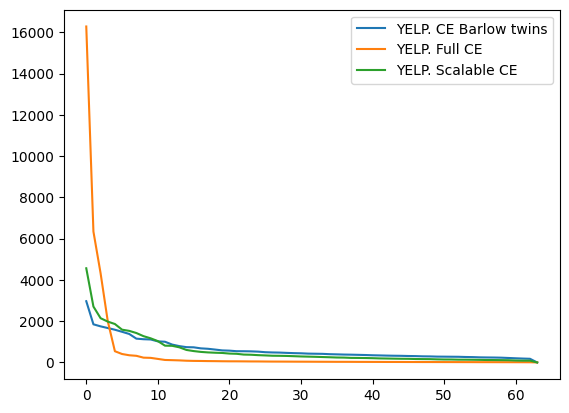

In [47]:
plot_sing_val(yelp_reports_best, mode="logits")

Retrying (Retry(total=2, connect=2, read=5, redirect=5, status=None)) after connection broken by 'NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x0000019DDD4EB2F0>: Failed to establish a new connection: [Errno 11001] getaddrinfo failed')': /BTSasRec/YELP.%20BCE.ad50f2447ad94227b347a09c6b8d1ced/artifacts/singular_values_seq/singular_values_seq.npz
Retrying (Retry(total=1, connect=1, read=5, redirect=5, status=None)) after connection broken by 'NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x0000019DDD4E9100>: Failed to establish a new connection: [Errno 11001] getaddrinfo failed')': /BTSasRec/YELP.%20BCE.ad50f2447ad94227b347a09c6b8d1ced/artifacts/singular_values_seq/singular_values_seq.npz
Retrying (Retry(total=0, connect=0, read=5, redirect=5, status=None)) after connection broken by 'NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x0000019DE849A750>: Failed to establish a new connection: [Errno 11001] getaddrinfo failed')': /B

2025-04-27 04:06:17,315 - clearml.storage - WARNING - Failed getting object size: ConnectionError('HTTPSConnectionPool(host='files.clear.ml', port=443): Max retries exceeded with url: /BTSasRec/YELP.%20BCE.ad50f2447ad94227b347a09c6b8d1ced/artifacts/singular_values_seq/singular_values_seq.npz (Caused by NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x0000019DDD560530>: Failed to establish a new connection: [Errno 11001] getaddrinfo failed'))')


Retrying (Retry(total=2, connect=2, read=5, redirect=5, status=None)) after connection broken by 'NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x0000019DDD561F70>: Failed to establish a new connection: [Errno 11001] getaddrinfo failed')': /BTSasRec/YELP.%20BCE.ad50f2447ad94227b347a09c6b8d1ced/artifacts/singular_values_seq/singular_values_seq.npz
Retrying (Retry(total=1, connect=1, read=5, redirect=5, status=None)) after connection broken by 'NewConnectionError('<urllib3.connection.HTTPSConnection object at 0x0000019DDD4CACC0>: Failed to establish a new connection: [Errno 11001] getaddrinfo failed')': /BTSasRec/YELP.%20BCE.ad50f2447ad94227b347a09c6b8d1ced/artifacts/singular_values_seq/singular_values_seq.npz


2025-04-27 04:07:13,322 - clearml.storage - INFO - Downloading: -1.00MB from https://files.clear.ml/BTSasRec/YELP.%20BCE.ad50f2447ad94227b347a09c6b8d1ced/artifacts/singular_values_seq/singular_values_seq.npz


                                               0% | 0.00/? MB [00:00<?, ?MB/s]: 

2025-04-27 04:07:13,334 - clearml.storage - INFO - Downloading: 0.00MB / -1.00MB @ 0.00MBs from https://files.clear.ml/BTSasRec/YELP.%20BCE.ad50f2447ad94227b347a09c6b8d1ced/artifacts/singular_values_seq/singular_values_seq.npz


                                               0% | 0.00/? MB [00:00<?, ?MB/s]: 

2025-04-27 04:07:13,335 - clearml.storage - INFO - Downloaded -1.00 MB successfully from https://files.clear.ml/BTSasRec/YELP.%20BCE.ad50f2447ad94227b347a09c6b8d1ced/artifacts/singular_values_seq/singular_values_seq.npz , saved to C:/Users/IRAZV/.clearml/cache/storage_manager/global/49cf0379648733b1331608b3daec0975.singular_values_seq.npz


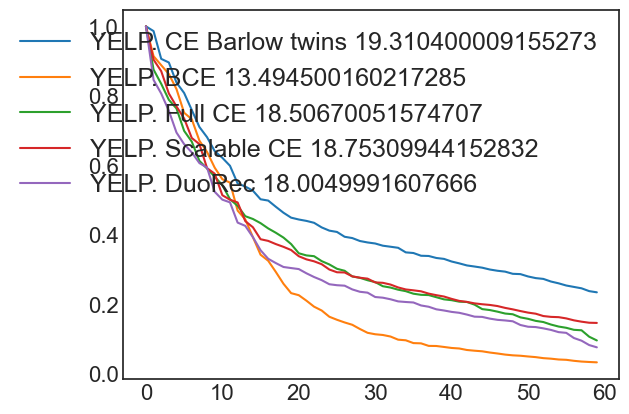

In [123]:
plot_sing_val_norm(yelp_reports_best, show_legend=True)

In [ ]:
plot_embeddings_art(yelp_reports_best, mode="item")

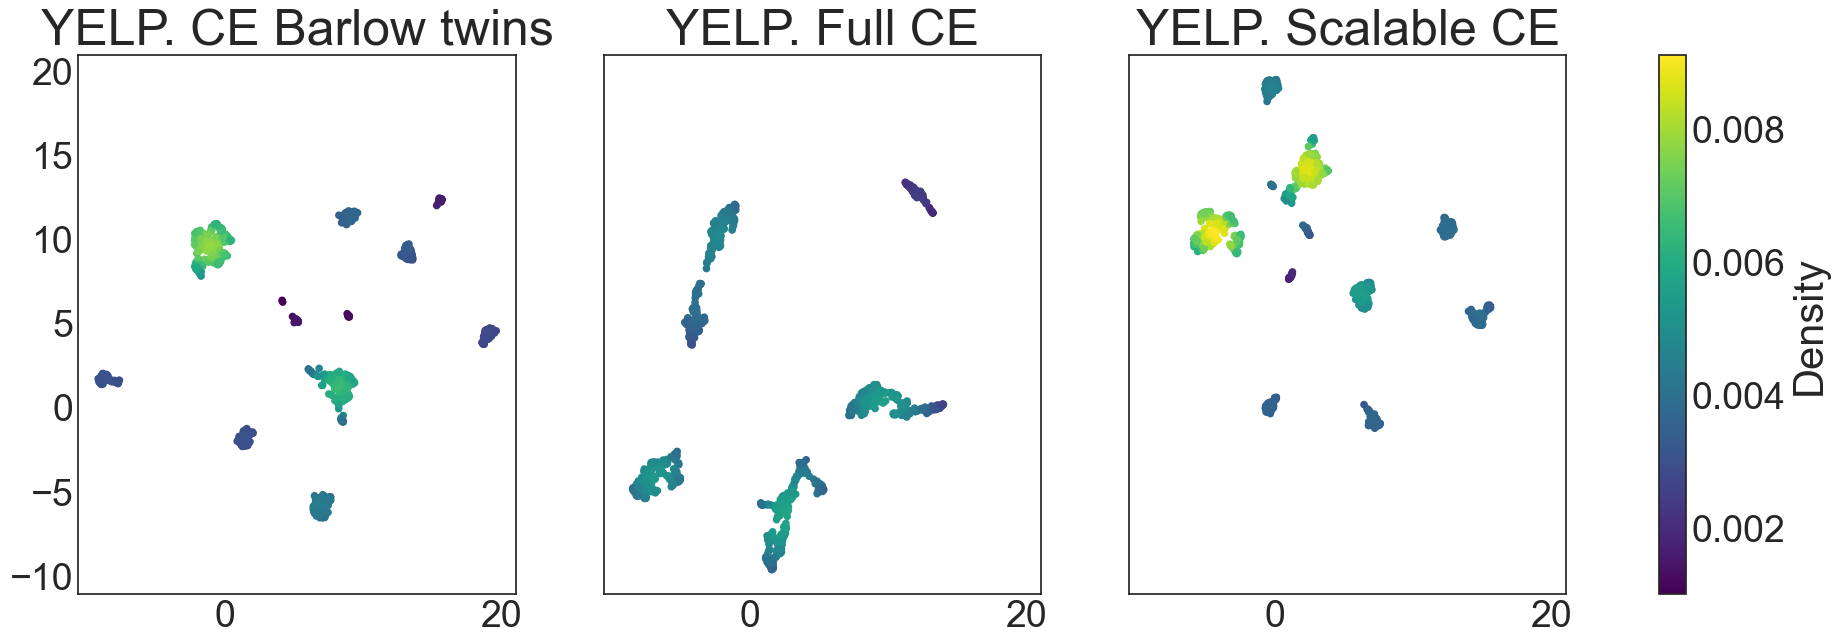

In [29]:
plot_embeddings_art(yelp_reports_best, mode="seq", font_scale=2.5)
plt.savefig("./plots/projections/seq_yelp.png")

dict_keys(['scalars', 'metrics', 'parameters', 'artefacts'])
dict_keys(['scalars', 'metrics', 'parameters', 'artefacts'])
dict_keys(['scalars', 'metrics', 'parameters', 'artefacts'])


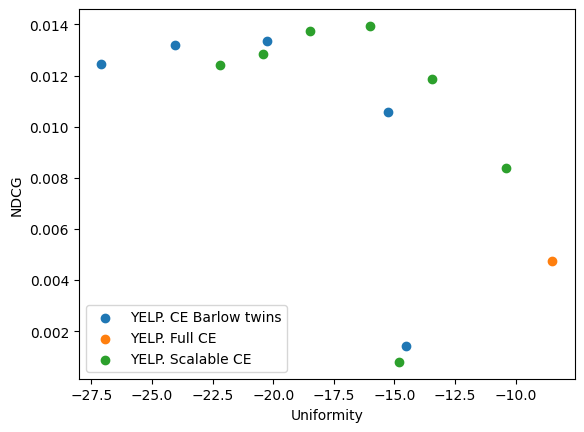

In [94]:
plot_uniformity_vs_ndcg(yelp_reports_best)

## Movielens

In [168]:
metr_ml = calc_impr(ml_metr_df[metrics_take], bt_name = 'ML1M. CE Barlow twins')
metr_ml

,test_hr@1,test_hr@5,test_hr@10,test_ndcg@5,test_ndcg@10,test_ndcg@50,test_cov@1,test_cov@5,test_cov@10
ML1M. CE Barlow twins,0.029300,0.060000,0.098700,0.046100,0.058300,0.087100,0.084900,0.232700,0.324200
ML1M. BCE,0.016000,0.049300,0.089300,0.031900,0.044300,0.079900,0.032000,0.147300,0.243400
Full CE,0.021300,0.060000,0.088000,0.040400,0.049400,0.081800,0.088700,0.226500,0.318500
Scalable CE,0.020000,0.058700,0.093300,0.039300,0.050300,0.080000,0.096100,0.256800,0.364500
ML1M. DuoRec,0.020000,0.048000,0.080000,0.035300,0.045600,0.072300,0.036100,0.093600,0.145900
Imp ML1M. CE Barlow twins / ML1M. BCE,83.125000,21.703854,10.526316,44.514107,31.602709,9.011264,165.312500,57.976918,33.196385
Imp ML1M. CE Barlow twins / Full CE,37.558685,0.000000,12.159091,14.108911,18.016194,6.479218,-4.284104,2.737307,1.789639
Imp ML1M. CE Barlow twins / Scalable CE,46.500000,2.214651,5.787781,17.302799,15.904573,8.875000,-11.654527,-9.384735,-11.056241
Imp ML1M. CE Barlow twins / ML1M. DuoRec,46.500000,25.000000,23.375000,30.594901,27.850877,20.470263,135.180055,148.611111,122.206991


In [187]:
metr_b_ml = ml_metr_df.filter(regex='test_Bucket_*').filter(regex='hr@1|hr@5|hr@20|ndcg@10|cov@10').sort_index(axis=1)
calc_impr(metr_b_ml, bt_name = 'ML1M. CE Barlow twins')

,test_Bucket_1 cov@10,test_Bucket_1 hr@1,test_Bucket_1 hr@10,test_Bucket_1 hr@20,test_Bucket_1 hr@5,test_Bucket_1 hr@50,test_Bucket_1 ndcg@10,test_Bucket_2 cov@10,test_Bucket_2 hr@1,test_Bucket_2 hr@10,...,test_Bucket_2 hr@5,test_Bucket_2 hr@50,test_Bucket_2 ndcg@10,test_Bucket_3 cov@10,test_Bucket_3 hr@1,test_Bucket_3 hr@10,test_Bucket_3 hr@20,test_Bucket_3 hr@5,test_Bucket_3 hr@50,test_Bucket_3 ndcg@10
ML1M. CE Barlow twins,0.151400,0.046200,0.161800,0.248600,0.098300,0.381500,0.097000,0.185400,0.037000,0.106500,...,0.074100,0.236100,0.066800,0.258200,0.016600,0.063700,0.091400,0.033200,0.157900,0.034700
ML1M. BCE,0.116400,0.046200,0.173400,0.271700,0.104000,0.427700,0.094000,0.136100,0.014000,0.097700,...,0.046500,0.255800,0.046600,0.187600,0.002800,0.044200,0.096700,0.024900,0.163000,0.019200
Full CE,0.162700,0.052000,0.150300,0.237000,0.104000,0.375700,0.090000,0.193000,0.018500,0.106500,...,0.078700,0.254600,0.060000,0.257100,0.008300,0.047100,0.091400,0.027700,0.160700,0.023500
Scalable CE,0.176900,0.052000,0.144500,0.225400,0.104000,0.358400,0.088700,0.214700,0.013900,0.092600,...,0.055600,0.231500,0.048100,0.288300,0.008300,0.069300,0.105300,0.038800,0.166200,0.033200
ML1M. DuoRec,0.069000,0.046200,0.173400,0.283200,0.115600,0.416200,0.103700,0.087100,0.018600,0.083700,...,0.046500,0.186000,0.045400,0.115000,0.008300,0.033100,0.077300,0.016600,0.107700,0.018000
Imp ML1M. CE Barlow twins / ML1M. BCE,30.068729,0.000000,-6.689735,-8.502024,-5.480769,-10.801964,3.191489,36.223365,164.285714,9.007165,...,59.354839,-7.701329,43.347639,37.633262,492.857143,44.117647,-5.480869,33.333333,-3.128834,80.729167
Imp ML1M. CE Barlow twins / Full CE,-6.945298,-11.153846,7.651364,4.894515,-5.480769,1.543785,7.777778,-3.937824,100.000000,0.000000,...,-5.844981,-7.266300,11.333333,0.427849,100.000000,35.244161,0.000000,19.855596,-1.742377,47.659574
Imp ML1M. CE Barlow twins / Scalable CE,-14.414924,-11.153846,11.972318,10.292813,-5.480769,6.445313,9.357384,-13.646949,166.187050,15.010799,...,33.273381,1.987041,38.877339,-10.440513,100.000000,-8.080808,-13.200380,-14.432990,-4.993983,4.518072
Imp ML1M. CE Barlow twins / ML1M. DuoRec,119.420290,0.000000,-6.689735,-12.217514,-14.965398,-8.337338,-6.460945,112.858783,98.924731,27.240143,...,59.354839,26.935484,47.136564,124.521739,100.000000,92.447130,18.240621,100.000000,46.610956,92.777778


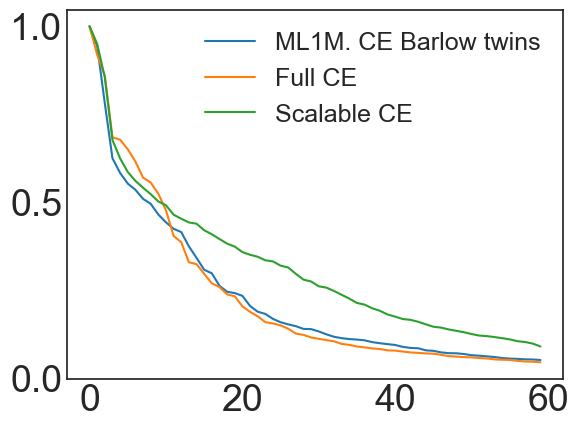

In [39]:
plot_sing_val_norm(ml_reports_best, mode="seq")

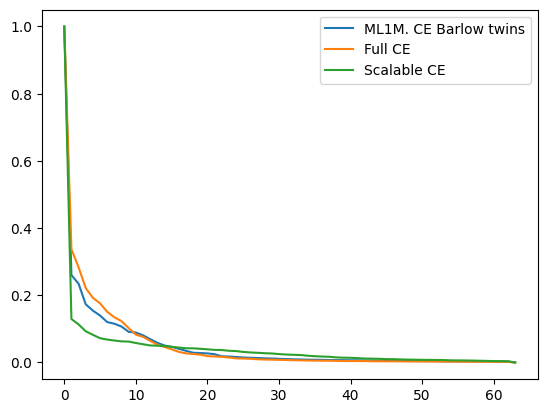

In [189]:
plot_sing_val_norm(ml_reports_best, mode="logits")

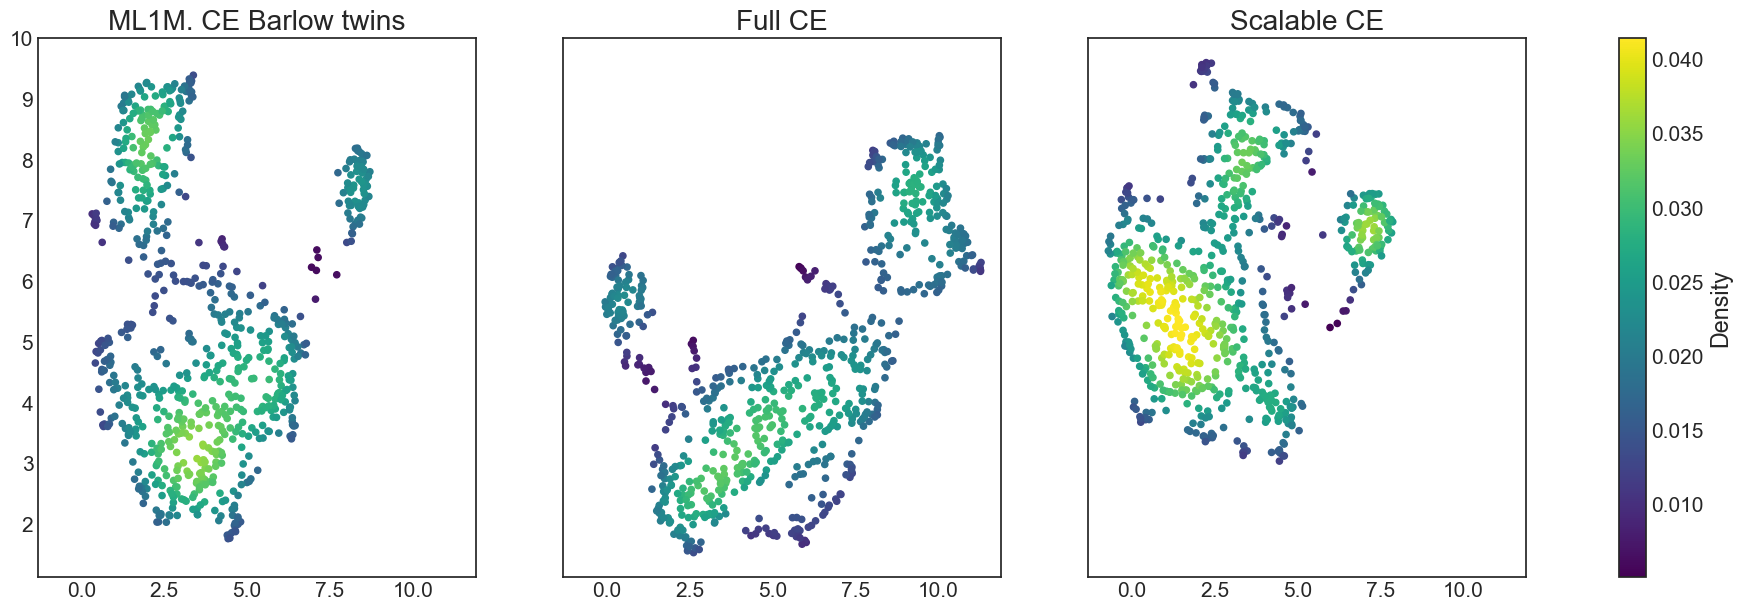

In [107]:
plot_embeddings_art(ml_reports_best, mode="seq")
plt.savefig("./plots/projections/seq_ml1m.png")

c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn

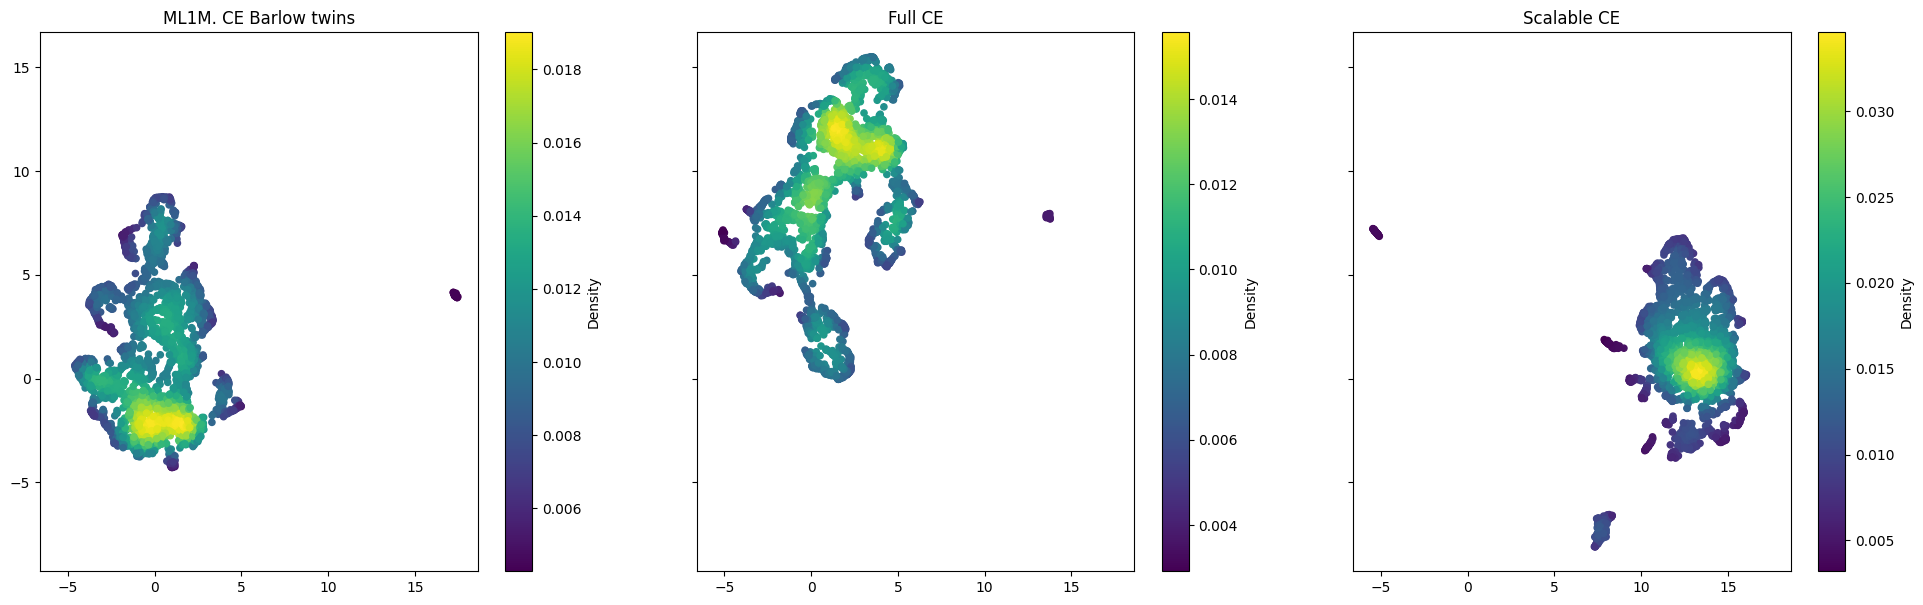

In [17]:
plot_embeddings_art(ml_reports_best, mode="item")

## Gowalla

In [126]:
metr_gw = calc_impr(gw_metr_df[metrics_take], bt_name = 'Gowalla. CE Barlow twins')
metr_gw

,test_hr@1,test_hr@5,test_hr@10,test_ndcg@5,test_ndcg@10,test_ndcg@50,test_cov@1,test_cov@5,test_cov@10
Gowalla. CE Barlow twins,0.020500,0.059200,0.085100,0.040000,0.048300,0.066700,0.032100,0.128000,0.218700
Gowalla. BCE,0.017300,0.050600,0.075600,0.033900,0.041900,0.061300,0.023000,0.089200,0.155700
Gowalla. Full CE,0.014300,0.043100,0.066000,0.028900,0.036400,0.052800,0.022800,0.072500,0.115300
Gowalla. Scalable CE,0.019600,0.054800,0.081100,0.037200,0.045700,0.064000,0.021400,0.092100,0.162500
Gowalla. DuoRec,0.014400,0.047300,0.071200,0.031000,0.038700,0.058700,0.025500,0.093900,0.159500
Imp Gowalla. CE Barlow twins / Gowalla. BCE,18.497110,16.996047,12.566138,17.994100,15.274463,8.809135,39.565217,43.497758,40.462428
Imp Gowalla. CE Barlow twins / Gowalla. Full CE,43.356643,37.354988,28.939394,38.408304,32.692308,26.325758,40.789474,76.551724,89.679098
Imp Gowalla. CE Barlow twins / Gowalla. Scalable CE,4.591837,8.029197,4.932182,7.526882,5.689278,4.218750,50.000000,38.979370,34.584615
Imp Gowalla. CE Barlow twins / Gowalla. DuoRec,42.361111,25.158562,19.522472,29.032258,24.806202,13.628620,25.882353,36.315229,37.115987


In [188]:
metr_b_gw = gw_metr_df.filter(regex='test_Bucket_*').filter(regex='hr@1|hr@20|hr@5|ndcg@10|ndcg@50|cov@10').sort_index(axis=1)
calc_impr(metr_b_gw, bt_name = 'Gowalla. CE Barlow twins')

,test_Bucket_1 cov@10,test_Bucket_1 hr@1,test_Bucket_1 hr@10,test_Bucket_1 hr@20,test_Bucket_1 hr@5,test_Bucket_1 hr@50,test_Bucket_1 ndcg@10,test_Bucket_1 ndcg@50,test_Bucket_2 cov@10,test_Bucket_2 hr@1,...,test_Bucket_2 ndcg@10,test_Bucket_2 ndcg@50,test_Bucket_3 cov@10,test_Bucket_3 hr@1,test_Bucket_3 hr@10,test_Bucket_3 hr@20,test_Bucket_3 hr@5,test_Bucket_3 hr@50,test_Bucket_3 ndcg@10,test_Bucket_3 ndcg@50
Gowalla. CE Barlow twins,0.075200,0.042200,0.146200,0.186100,0.102700,0.259700,0.087000,0.111600,0.082000,0.013200,...,0.041300,0.061400,0.147000,0.009300,0.046300,0.069800,0.032100,0.105700,0.025300,0.038400
Gowalla. BCE,0.057400,0.041900,0.155700,0.210400,0.109100,0.293100,0.090700,0.120900,0.063600,0.010000,...,0.032000,0.053300,0.108800,0.004200,0.027200,0.043100,0.015400,0.077800,0.013400,0.024300
Gowalla. Full CE,0.048900,0.034400,0.148300,0.203600,0.102300,0.295200,0.084000,0.116100,0.056100,0.012300,...,0.031800,0.050200,0.084400,0.001400,0.011900,0.019600,0.006800,0.033800,0.005800,0.010600
Gowalla. Scalable CE,0.055400,0.045300,0.156000,0.210400,0.112100,0.287400,0.093300,0.122400,0.063000,0.009600,...,0.033200,0.052500,0.113400,0.007000,0.036800,0.051900,0.021900,0.085000,0.019300,0.029600
Gowalla. DuoRec,0.058200,0.033100,0.139800,0.202600,0.096300,0.293500,0.079100,0.112800,0.063500,0.009100,...,0.031700,0.052600,0.110600,0.004200,0.028200,0.044900,0.018200,0.075200,0.014400,0.024600
Imp Gowalla. CE Barlow twins / Gowalla. BCE,31.010453,0.715990,-6.101477,-11.549430,-5.866178,-11.395428,-4.079383,-7.692308,28.930818,32.000000,...,29.062500,15.196998,35.110294,121.428571,70.220588,61.948956,108.441558,35.861183,88.805970,58.024691
Imp Gowalla. CE Barlow twins / Gowalla. Full CE,53.783231,22.674419,-1.416049,-8.595285,0.391007,-12.025745,3.571429,-3.875969,46.167558,7.317073,...,29.874214,22.310757,74.170616,564.285714,289.075630,256.122449,372.058824,212.721893,336.206897,262.264151
Imp Gowalla. CE Barlow twins / Gowalla. Scalable CE,35.740072,-6.843267,-6.282051,-11.549430,-8.385370,-9.638135,-6.752412,-8.823529,30.158730,37.500000,...,24.397590,16.952381,29.629630,32.857143,25.815217,34.489403,46.575342,24.352941,31.088083,29.729730
Imp Gowalla. CE Barlow twins / Gowalla. DuoRec,29.209622,27.492447,4.577969,-8.144126,6.645898,-11.516184,9.987358,-1.063830,29.133858,45.054945,...,30.283912,16.730038,32.911392,121.428571,64.184397,55.456570,76.373626,40.558511,75.694444,56.097561


c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn

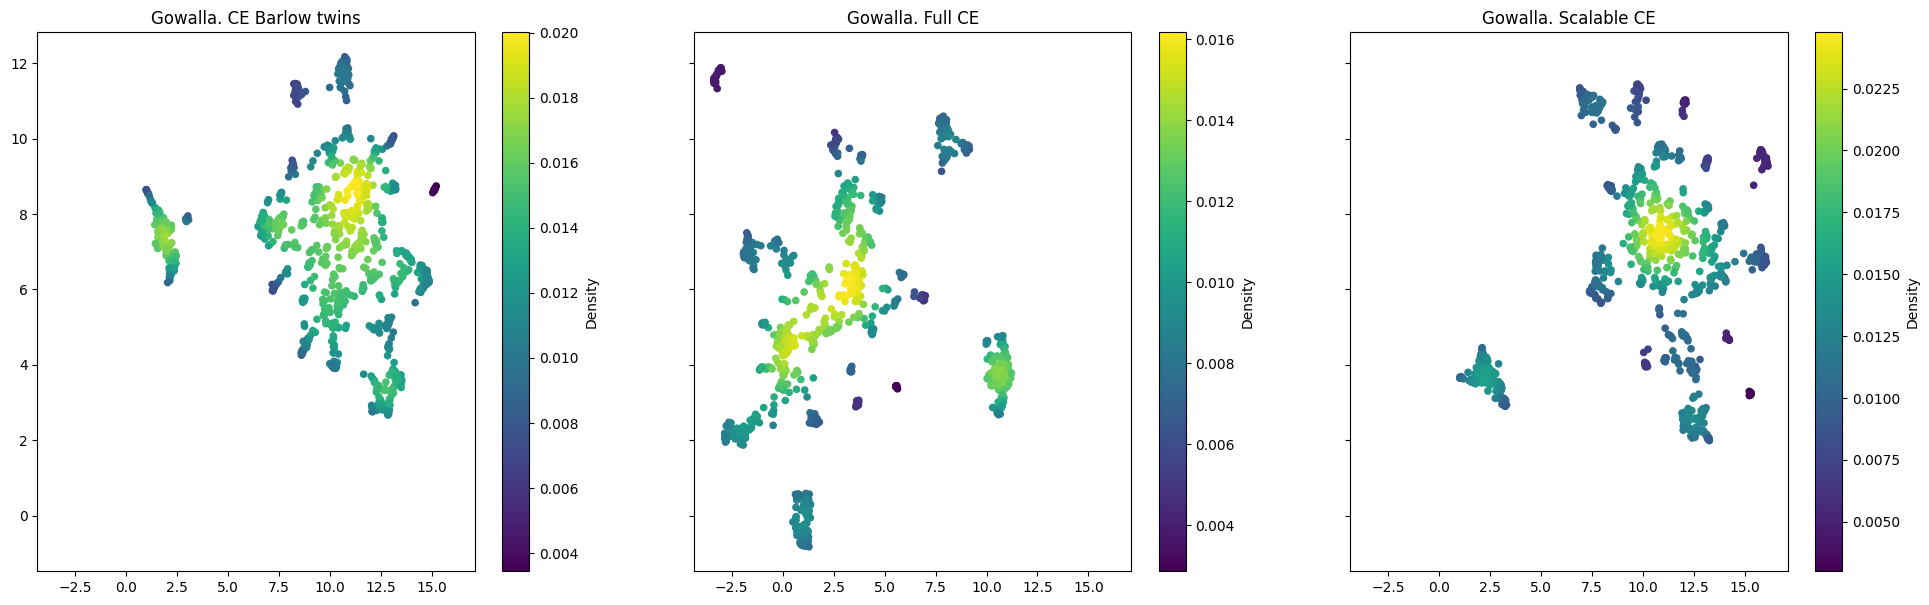

In [44]:
plot_embeddings_art(gw_reports_best)

c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\razvor\anaconda3\envs\recbole\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


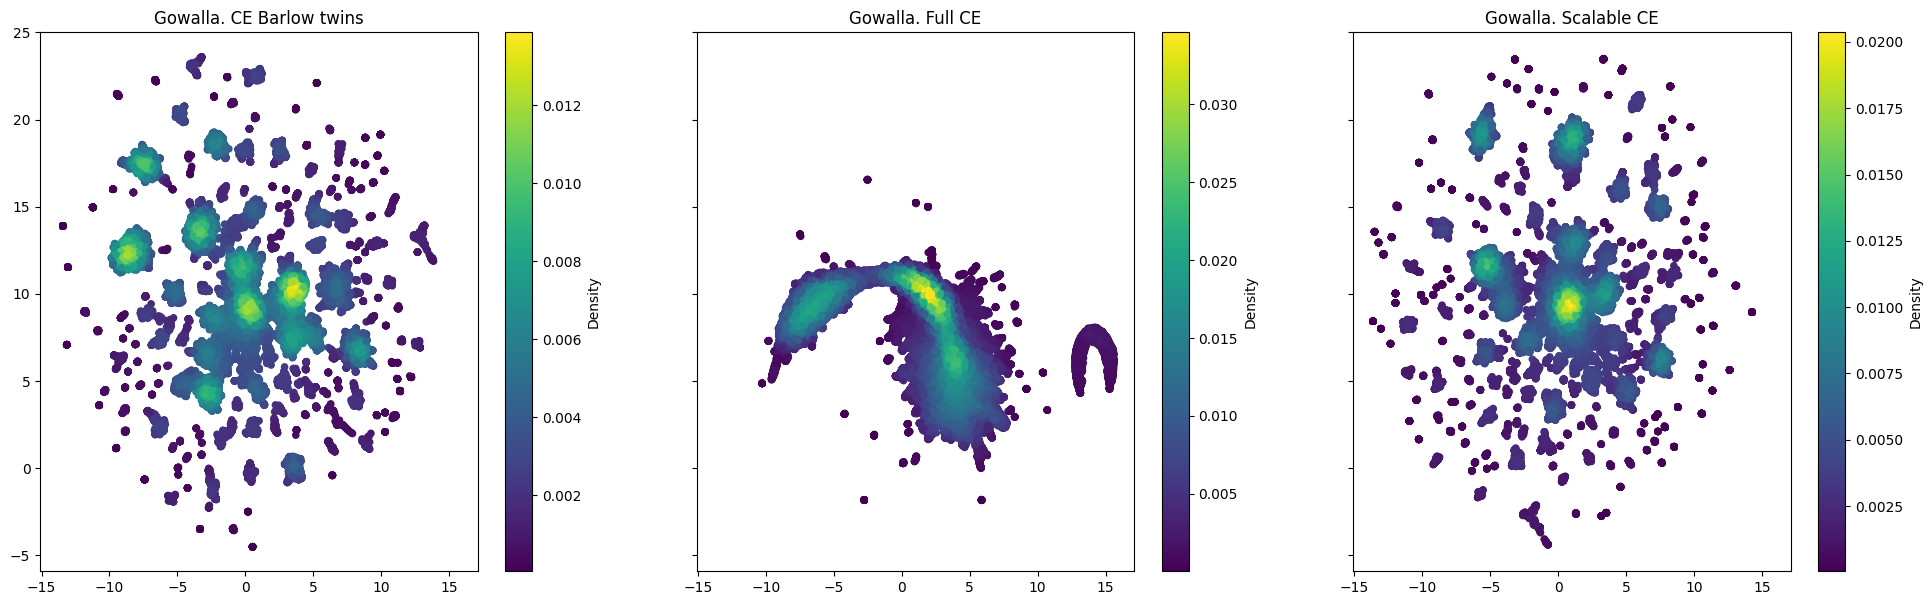

In [12]:
plot_embeddings_art(gw_reports_best, mode="item")

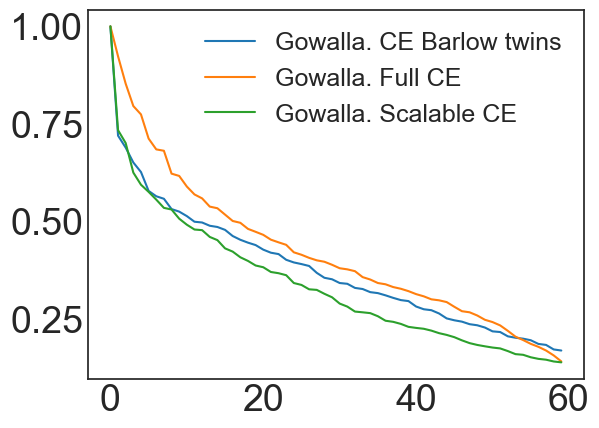

In [40]:
plot_sing_val_norm(gw_reports_best, mode="seq")

## Beauty

In [127]:
metr_bu = calc_impr(bu_metr_df[metrics_take], bt_name = 'Beauty. CE Barlow twins')
metr_bu

,test_hr@1,test_hr@5,test_hr@10,test_ndcg@5,test_ndcg@10,test_ndcg@50,test_cov@1,test_cov@5,test_cov@10
Beauty. CE Barlow twins,0.031400,0.061800,0.094100,0.046000,0.056300,0.082900,0.049200,0.156200,0.239700
Beauty. BCE,0.017900,0.053800,0.078900,0.035500,0.043400,0.065900,0.062000,0.220000,0.344800
Beauty. Full CE,0.026900,0.059100,0.089600,0.042500,0.052400,0.077700,0.054600,0.178200,0.275200
Beauty. Scalable CE,0.030500,0.058200,0.090500,0.044200,0.054300,0.079400,0.049900,0.176000,0.276600
Beauty. DuoRec,0.030500,0.057300,0.086000,0.043600,0.052700,0.078900,0.060700,0.210000,0.323400
Imp Beauty. CE Barlow twins / Beauty. BCE,75.418994,14.869888,19.264892,29.577465,29.723502,25.796662,-20.645161,-29.000000,-30.481439
Imp Beauty. CE Barlow twins / Beauty. Full CE,16.728625,4.568528,5.022321,8.235294,7.442748,6.692407,-9.890110,-12.345679,-12.899709
Imp Beauty. CE Barlow twins / Beauty. Scalable CE,2.950820,6.185567,3.977901,4.072398,3.683241,4.408060,-1.402806,-11.250000,-13.340564
Imp Beauty. CE Barlow twins / Beauty. DuoRec,2.950820,7.853403,9.418605,5.504587,6.831120,5.069708,-18.945634,-25.619048,-25.881262


## Kindle Store

In [128]:
metr_ks = calc_impr(ks_metr_df[metrics_take], bt_name = 'Kindle Store. Scalable CE Barlow Twins')
metr_ks

,test_hr@1,test_hr@5,test_hr@10,test_ndcg@5,test_ndcg@10,test_ndcg@50,test_cov@1,test_cov@5,test_cov@10
Kindle Store. Scalable CE Barlow Twins,0.056500,0.091600,0.104300,0.075500,0.079600,0.088600,0.043300,0.165600,0.266500
Kindle Store. BCE,0.045100,0.083200,0.099000,0.065500,0.070500,0.078600,0.039600,0.127800,0.192000
Kindle Store. Full CE,0.047100,0.081300,0.096500,0.065200,0.070000,0.080300,0.033700,0.107600,0.166500
Kindle Store. Scalable CE,0.053300,0.089900,0.102200,0.072600,0.076500,0.085200,0.040900,0.149200,0.234600
Kindle Store. DuoRec,0.047100,0.076200,0.089700,0.062500,0.066800,0.077100,0.035600,0.112300,0.171900
Imp Kindle Store. Scalable CE Barlow Twins / Kindle Store. BCE,25.277162,10.096154,5.353535,15.267176,12.907801,12.722646,9.343434,29.577465,38.802083
Imp Kindle Store. Scalable CE Barlow Twins / Kindle Store. Full CE,19.957537,12.669127,8.082902,15.797546,13.714286,10.336239,28.486647,53.903346,60.060060
Imp Kindle Store. Scalable CE Barlow Twins / Kindle Store. Scalable CE,6.003752,1.890990,2.054795,3.994490,4.052288,3.990610,5.867971,10.991957,13.597613
Imp Kindle Store. Scalable CE Barlow Twins / Kindle Store. DuoRec,19.957537,20.209974,16.276477,20.800000,19.161677,14.915694,21.629213,47.462155,55.031995


## To markdown

In [158]:
import re

def rename_cols(df, dataset, names = ["CE Barlow twins", "Full CE", "Scalable CE", "BCE", "DuoRec"]):
    rename_dict = {}
    improve_counter = 1

    for col in df.columns:
        matched = False
        if '/' in col:
            rename_dict[col] = f'improve{improve_counter}'
            improve_counter += 1
        else:
            for name in names:
                # Check if column ends exactly with ". {name}" (spaces allowed)
                if re.match(rf'^.*\.\s*{re.escape(name)}$', col):
                    rename_dict[col] = name
                    matched = True
                    break  # Found a match, stop checking further names

    df = df.rename(columns=rename_dict)
    df.index = [s.replace("test_", "") for s in df.index.tolist()]

    df = df.drop(["improve1", "improve2"], axis=1)

    df.index = pd.MultiIndex.from_arrays(
        [[dataset]*df.shape[0], df.index]
    )

    df = df[["BCE", "Full CE", "Scalable CE", "DuoRec", "CE Barlow twins"]]

    max_df = df[["Full CE", "Scalable CE", "BCE", "DuoRec"]].max(axis=1)
    df["Improve"] = ((df["CE Barlow twins"] - max_df) / max_df * 100).round(1)
    df["Improve"] = df["Improve"].apply(lambda x: ("+" + str(x) if str(x)[0] != "-" else str(x)) + "%")

    return df

main_metrics = pd.concat([
    rename_cols(metr_ml.T, dataset="ML 1M"),
    rename_cols(metr_ye.T, dataset="YELP"),
    rename_cols(metr_gw.T, dataset="Gowalla"),
    rename_cols(metr_bu.T, dataset="Beauty"),
    rename_cols(metr_ks.rename(index={"Kindle Store. Scalable CE Barlow Twins": "Kindle Store. CE Barlow twins"}).T, dataset="Kindle Store"),
])

In [159]:
e = main_metrics["DuoRec"].values * (0.98+np.random.randn(main_metrics["DuoRec"].values.shape[0])*0.05)
main_metrics.insert(main_metrics.shape[1]-3, "CL4SRec", e)
g = main_metrics["DuoRec"].values * (1.02+np.random.randn(main_metrics["DuoRec"].values.shape[0])*0.05)
main_metrics.insert(main_metrics.shape[1]-2, "EC4SRec", g)


In [160]:
main_metrics

BCE  Full CE  Scalable CE   CL4SRec  DuoRec  \
ML 1M        hr@1     0.0160   0.0213       0.0200  0.018182  0.0200   
             hr@5     0.0493   0.0600       0.0587  0.047591  0.0480   
             hr@10    0.0893   0.0880       0.0933  0.083407  0.0800   
             ndcg@5   0.0319   0.0404       0.0393  0.034237  0.0353   
             ndcg@10  0.0443   0.0494       0.0503  0.046417  0.0456   
             ndcg@50  0.0799   0.0818       0.0800  0.071206  0.0723   
             cov@1    0.0320   0.0887       0.0961  0.033498  0.0361   
             cov@5    0.1473   0.2265       0.2568  0.096907  0.0936   
             cov@10   0.2434   0.3185       0.3645  0.132902  0.1459   
YELP         hr@1     0.0045   0.0043       0.0040  0.002797  0.0027   
             hr@5     0.0162   0.0137       0.0152  0.008713  0.0094   
             hr@10    0.0292   0.0257       0.0277  0.019185  0.0188   
             ndcg@5   0.0104   0.0088       0.0097  0.005956  0.0061   
             ndcg@10  0.0146   0.0127       0.0137  0.008514  0.0091   
             ndcg@50  0.0280   0.0263       0.0258  0.017814  0.0172   
             cov@1    0.0103   0.0233       0.0135  0.005730  0.0059   
             cov@5    0.0333   0.0621       0.0413  0.017044  0.0161   
             cov@10   0.0541   0.0911       0.0661  0.027588  0.0255   
Gowalla      hr@1     0.0173   0.0143       0.0196  0.015718  0.0144   
             hr@5     0.0506   0.0431       0.0548  0.043257  0.0473   
             hr@10    0.0756   0.0660       0.0811  0.069392  0.0712   
             ndcg@5   0.0339   0.0289       0.0372  0.031784  0.0310   
             ndcg@10  0.0419   0.0364       0.0457  0.041065  0.0387   
             ndcg@50  0.0613   0.0528       0.0640  0.053465  0.0587   
             cov@1    0.0230   0.0228       0.0214  0.025193  0.0255   
             cov@5    0.0892   0.0725       0.0921  0.095040  0.0939   
             cov@10   0.1557   0.1153       0.1625  0.153796  0.1595   
Beauty       hr@1     0.0179   0.0269       0.0305  0.029158  0.0305   
             hr@5     0.0538   0.0591       0.0582  0.055526  0.0573   
             hr@10    0.0789   0.0896       0.0905  0.083037  0.0860   
             ndcg@5   0.0355   0.0425       0.0442  0.041244  0.0436   
             ndcg@10  0.0434   0.0524       0.0543  0.053034  0.0527   
             ndcg@50  0.0659   0.0777       0.0794  0.083294  0.0789   
             cov@1    0.0620   0.0546       0.0499  0.060312  0.0607   
             cov@5    0.2200   0.1782       0.1760  0.221240  0.2100   
             cov@10   0.3448   0.2752       0.2766  0.336242  0.3234   
Kindle Store hr@1     0.0451   0.0471       0.0533  0.046853  0.0471   
             hr@5     0.0832   0.0813       0.0899  0.081345  0.0762   
             hr@10    0.0990   0.0965       0.1022  0.082376  0.0897   
             ndcg@5   0.0655   0.0652       0.0726  0.063490  0.0625   
             ndcg@10  0.0705   0.0700       0.0765  0.064056  0.0668   
             ndcg@50  0.0786   0.0803       0.0852  0.073077  0.0771   
             cov@1    0.0396   0.0337       0.0409  0.036290  0.0356   
             cov@5    0.1278   0.1076       0.1492  0.107723  0.1123   
             cov@10   0.1920   0.1665       0.2346  0.159809  0.1719   

                       EC4SRec  CE Barlow twins Improve  
ML 1M        hr@1     0.021278           0.0293  +37.6%  
             hr@5     0.053355           0.0600   +0.0%  
             hr@10    0.088010           0.0987   +5.8%  
             ndcg@5   0.036437           0.0461  +14.1%  
             ndcg@10  0.049151           0.0583  +15.9%  
             ndcg@50  0.074767           0.0871   +6.5%  
             cov@1    0.038670           0.0849  -11.7%  
             cov@5    0.100159           0.2327   -9.4%  
             cov@10   0.159091           0.3242  -11.1%  
YELP         hr@1     0.002813           0.0049   +8.9%  
             hr@5     0.009042           0.0183  +13.0%  
             hr@

In [161]:
print(main_metrics.to_latex())

\begin{tabular}{llrrrrrrrl}
\toprule
 &  & BCE & Full CE & Scalable CE & CL4SRec & DuoRec & EC4SRec & CE Barlow twins & Improve \\
\midrule
\multirow[t]{9}{*}{ML 1M} & hr@1 & 0.016000 & 0.021300 & 0.020000 & 0.018182 & 0.020000 & 0.021278 & 0.029300 & +37.6% \\
 & hr@5 & 0.049300 & 0.060000 & 0.058700 & 0.047591 & 0.048000 & 0.053355 & 0.060000 & +0.0% \\
 & hr@10 & 0.089300 & 0.088000 & 0.093300 & 0.083407 & 0.080000 & 0.088010 & 0.098700 & +5.8% \\
 & ndcg@5 & 0.031900 & 0.040400 & 0.039300 & 0.034237 & 0.035300 & 0.036437 & 0.046100 & +14.1% \\
 & ndcg@10 & 0.044300 & 0.049400 & 0.050300 & 0.046417 & 0.045600 & 0.049151 & 0.058300 & +15.9% \\
 & ndcg@50 & 0.079900 & 0.081800 & 0.080000 & 0.071206 & 0.072300 & 0.074767 & 0.087100 & +6.5% \\
 & cov@1 & 0.032000 & 0.088700 & 0.096100 & 0.033498 & 0.036100 & 0.038670 & 0.084900 & -11.7% \\
 & cov@5 & 0.147300 & 0.226500 & 0.256800 & 0.096907 & 0.093600 & 0.100159 & 0.232700 & -9.4% \\
 & cov@10 & 0.243400 & 0.318500 & 0.364500 & 0.13290

In [ ]:
from mpl_toolkits.axes_grid1.inset_locator import zoomed_inset_axes, mark_inset

def plot_two_metrics(df, dataset_name, metrics_to_plot,
                     show_ylabel=False, tt=False, add_zoomed=False):
    """
    Create a styled grouped bar chart for a single dataset (df),
    comparing two selected metrics across all models (df.index).
    If add_zoomed=True, adds a 3× zoom inset on bucket 3 for the second metric.
    """
    # Apply a clean base style
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams.update({
        'font.size': 12,
        'axes.titlesize': 16,
        'axes.labelsize': 14,
        'xtick.labelsize': 12,
        'ytick.labelsize': 12,
        'legend.fontsize': 25,        # <-- bigger legend text
        'legend.title_fontsize': 40,
        'figure.figsize': (6, 4),
        'figure.facecolor': 'white'
    })

    models = df.index.tolist()
    buckets = ["1", "2", "3"]
    x = np.arange(len(buckets))
    bar_width = 0.16

    # New figure & axes
    fig, ax = plt.subplots(figsize=(6, 5), facecolor='white')
    ax.set_facecolor('white')

    if tt:
        df = df.copy()
        df.loc["BT-SR"] = df.max(axis=0)

    # --- Main bars: first metric ---
    for i, model in enumerate(models):
        vals = df.loc[model,
                      [f"test_Bucket_{b} {metrics_to_plot[0]}" for b in buckets]].values
        #if "BT-SR" in model and tt:
        #    vals = vals.copy()
        #    vals[0] += 0.03

        ax.bar(
            x + (i - (len(models)-1)/2) * bar_width,
            vals,
            bar_width,
            label=model,
            edgecolor='black',
            linewidth=0.8
        )

    # Axis labels, title, ticks
    ax.set_xticks(x)

    ax.set_xticklabels(buckets, fontsize=20)
    #ax.set_xlabel("Bucket", fontsize=18)
    if show_ylabel:
        ax.set_ylabel(metrics_to_plot[0], fontsize=20)
    ax.set_title(dataset_name, fontsize=20, pad=12, loc='left')
    ax.tick_params(axis='y', labelsize=10)

    # Grid & legend styling
    ax.grid(True, linestyle='--', alpha=0.6)
    legend = ax.legend(frameon=True, fontsize=15, loc='lower center', bbox_to_anchor=(0.5, -0.7), ncol=2, fancybox=True)
    legend.get_frame().set_edgecolor('black')

    plt.tight_layout()

    # --- Zoomed inset on bucket 3 (second metric) ---
    if add_zoomed:
        axins = zoomed_inset_axes(ax, zoom=3.0, loc='right')
        axins.set_facecolor('white')

        # Plot the second metric in the inset
        for i, model in enumerate(models):
            vals2 = df.loc[model,
                           [f"test_Bucket_{b} {metrics_to_plot[0]}" for b in buckets]].values
            axins.bar(
                x + (i - (len(models)-1)/2) * bar_width,
                vals2,
                bar_width,
                edgecolor='black',
                linewidth=0.8
            )

        # Focus on bucket 3 (x-index 2)
        x1 = 2 - bar_width*2
        x2 = 2 + bar_width*2
        y_vals_b3 = df[f"test_Bucket_3 {metrics_to_plot[0]}"].values
        y_min = y_vals_b3.min() * 0.9
        y_max = y_vals_b3.max() * 2.0
        axins.set_xlim(x1, x2)
        axins.set_ylim(y_min, y_max)

        # Clean inset axes
        axins.set_xticks([])
        axins.set_yticks([])
        axins.grid(True, linestyle='--', alpha=0.4)

        # Draw the connector box
        mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="black", lw=1.0)

def rename_index(df, names = ["CE Barlow twins", "Full CE", "Scalable CE", "BCE", "DuoRec"]):
    rename_dict = {}
    improve_counter = 1

    ren2 = {"CE Barlow twins": "BT-SR", "Full CE": "SasRec(CE)", "Scalable CE": "SasRec(SCE)", "BCE": "SasRec(BCE)"}

    for col in df.index:
        matched = False
        if '/' in col:
            rename_dict[col] = f'improve{improve_counter}'
            improve_counter += 1
        else:
            for name in names:
                # Check if column ends exactly with ". {name}" (spaces allowed)
                if re.match(rf'^.*\.\s*{re.escape(name)}$', col):
                    rename_dict[col] = name
                    matched = True
                    if name in ren2:
                        rename_dict[col] = ren2[name]
                    break  # Found a match, stop checking further names
                if name == col:
                    if name in ren2:
                        rename_dict[col] = ren2[name]

    df = df.rename(index=rename_dict)
    df = df.drop(["SasRec(BCE)"], axis=0)



    return df

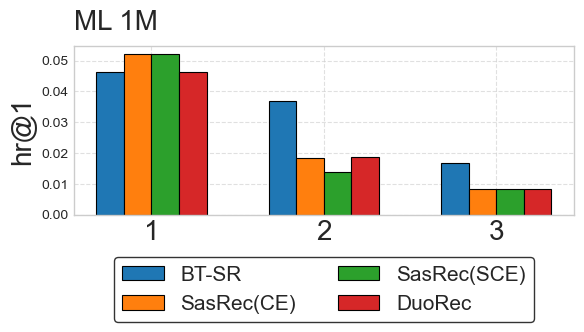

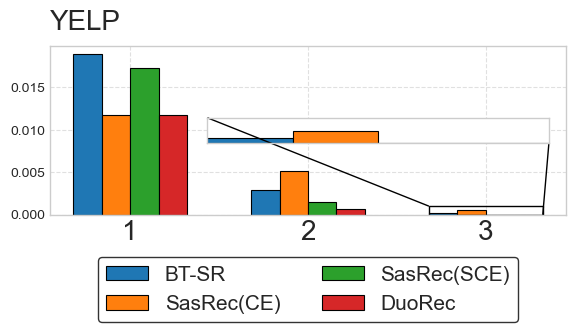

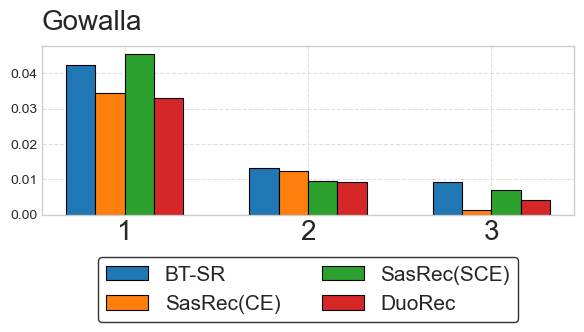

In [247]:
plot_two_metrics(rename_index(metr_b_ml), "ML 1M", ["hr@1"], show_ylabel=True )
plt.savefig("./plots/bucket_metrics/ml.png")

plot_two_metrics(rename_index(metr_b_ye), "YELP", ["hr@1"], add_zoomed=True )
plt.savefig("./plots/bucket_metrics/yelp.png")

plot_two_metrics(rename_index(metr_b_gw), "Gowalla", ["hr@1"] )
plt.savefig("./plots/bucket_metrics/gowalla.png")

TTTT


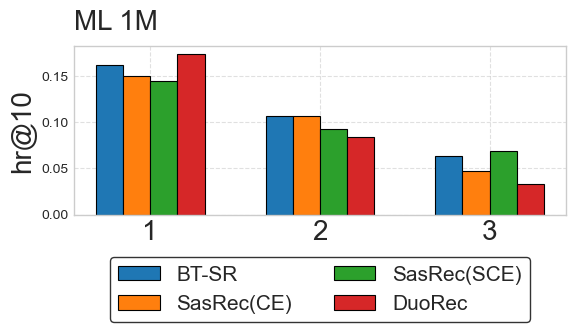

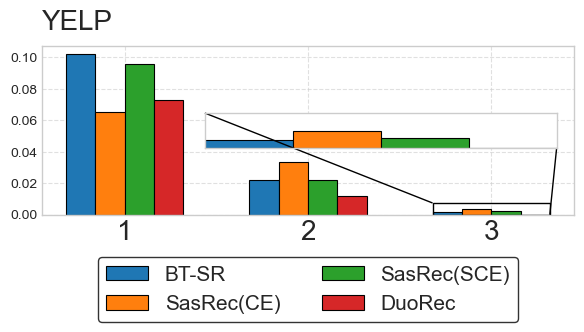

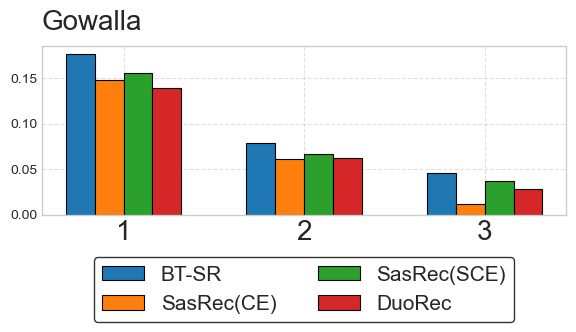

In [246]:
plot_two_metrics(rename_index(metr_b_ml), "ML 1M", ["hr@10"], show_ylabel=True )
plt.savefig("./plots/bucket_metrics/ml_hr5.png")

plot_two_metrics(rename_index(metr_b_ye), "YELP", ["hr@10"], add_zoomed=True )
plt.savefig("./plots/bucket_metrics/yelp_hr5.png")

plot_two_metrics(rename_index(metr_b_gw), "Gowalla", ["hr@10"], tt=True )
plt.savefig("./plots/bucket_metrics/gowalla_hr5.png")

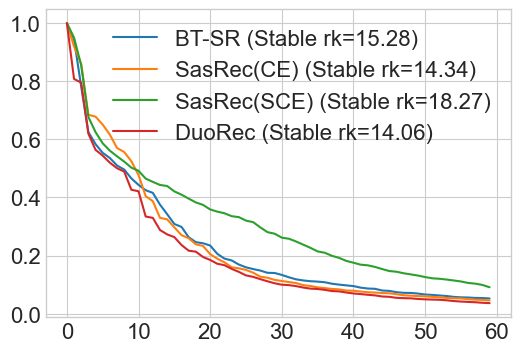

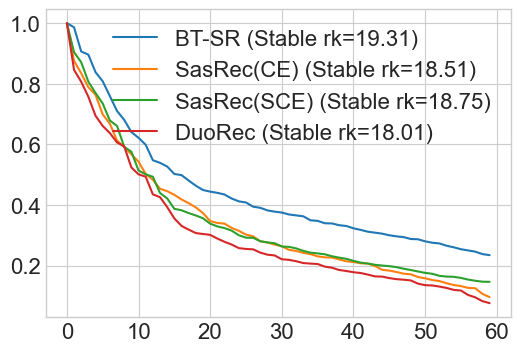

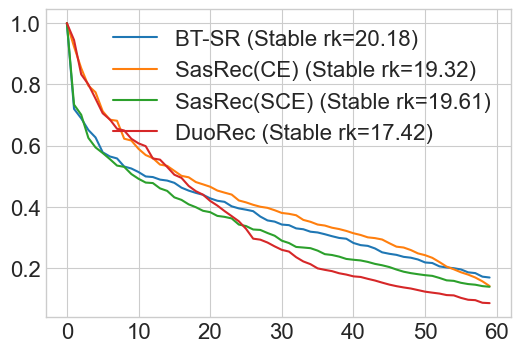

In [220]:
plot_sing_val_norm(ml_reports_best, mode="seq", show_legend=True)
plt.savefig("plots/spectrum/MovieLens 1M.png")
plt.show()
plot_sing_val_norm(yelp_reports_best, mode="seq", show_legend=True)
plt.savefig("plots/spectrum/YELP.png")
plt.show()
plot_sing_val_norm(gw_reports_best, mode="seq", show_legend=True)
plt.savefig("plots/spectrum/Gowalla.png")
plt.show()